# Internals of Python

* [Motivation](#Motivation)
* [Execution](#Execution)
    * [Compiled vs Interpreted](#Compiled-vs-Interpreted)
    * [Bytecode](#Bytecode)
    * [.pyc](#.pyc)
* [CPython](#CPython)
    * [Source structure](#Source-structure)
    * [Simple program](#Simple-program)
    * [Compilation](#Compilation)
    * [Code objects](#Code-objects)
    * [Frames](#Frames)
    * [Eval loop](#Eval-loop)
    * [Object](#Object) 

## Motivation

__Goal__

* разобраться с устройством виртуальной машины;
* рассмотреть процесс исполнения кода;
* рассмотреть фундаментальные абстракции, которыми оперирует виртуальная машины.

__Homework: Интерпретатор__

Взять готовый интерпретатор Python, написанный на Python и адаптировать его по современную версию языка.

## Execution

#### Compiled vs Interpreted

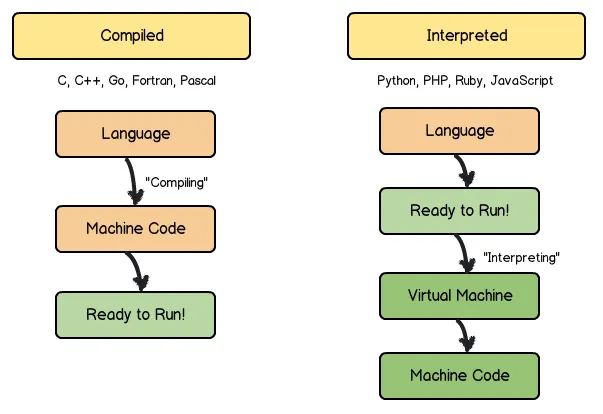

* Implementation dependent
    * CPython: default
* CPython is interptreted
    * "compiles" to bytecode
    * interpretes bytecode
    * CPython = compiler + VM
* Python Virtual machine (PVM)
    * simple stack machine
* Machine code v.s bytecode
    * machine code is faster
    * bytecode is portable

#### Alternative VMs

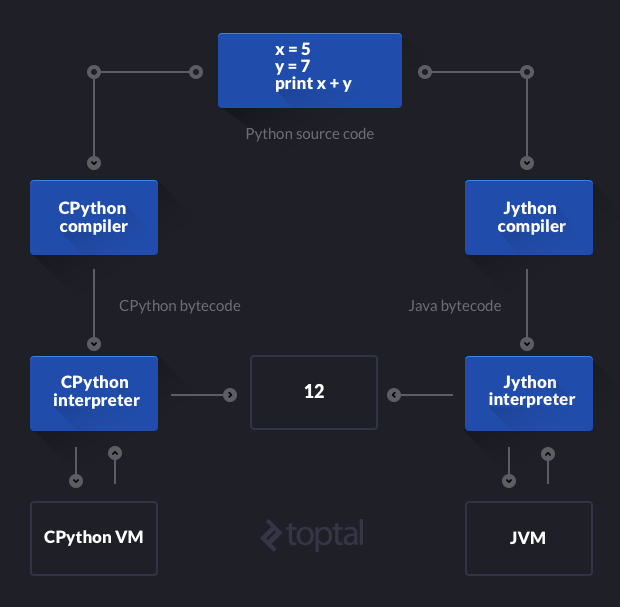

#### Webassembly

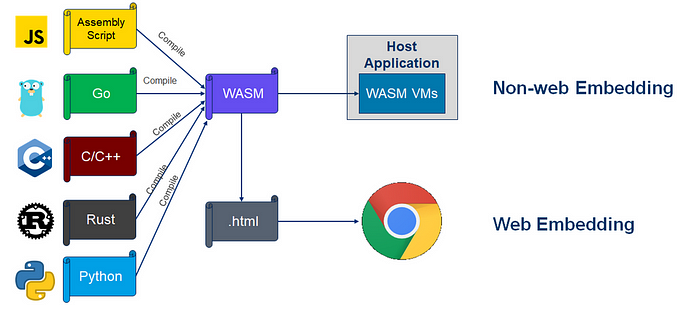

#### Bytecode

<center><div>
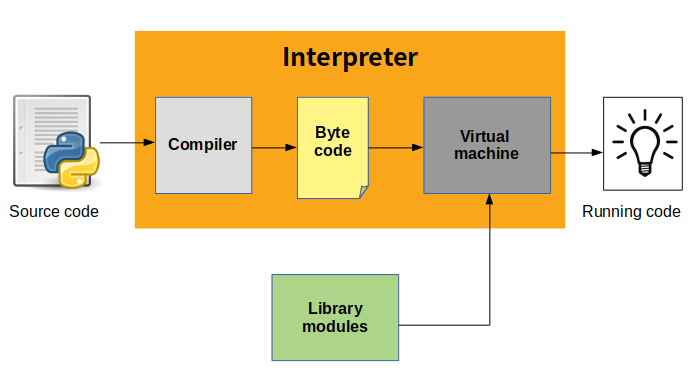
</div></center>

In [21]:
import dis

def add(a, b):
    return a + b

bytecode = add.__code__.co_code
print(f"Actual bytecode {bytecode} and it's disaasembly\n")
dis.dis(add)

Actual bytecode b'\x95\x00X\x01-\x00\x00\x00$\x00' and it's disaasembly

  3           RESUME                   0

  4           LOAD_FAST_LOAD_FAST      1 (a, b)
              BINARY_OP                0 (+)
              RETURN_VALUE


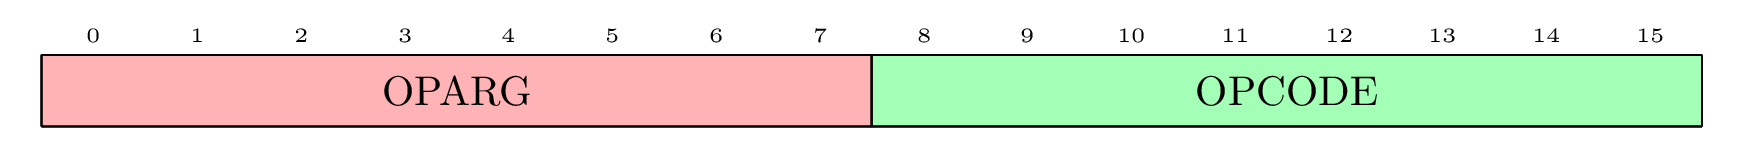

#### Specializing adaptive intepreter and copy-and-patch JIT

* https://docs.python.org/3.13/whatsnew/3.11.html#pep-659-specializing-adaptive-interpreter
* https://docs.python.org/3.13/whatsnew/3.13.html#experimental-jit-compiler

<center><div>
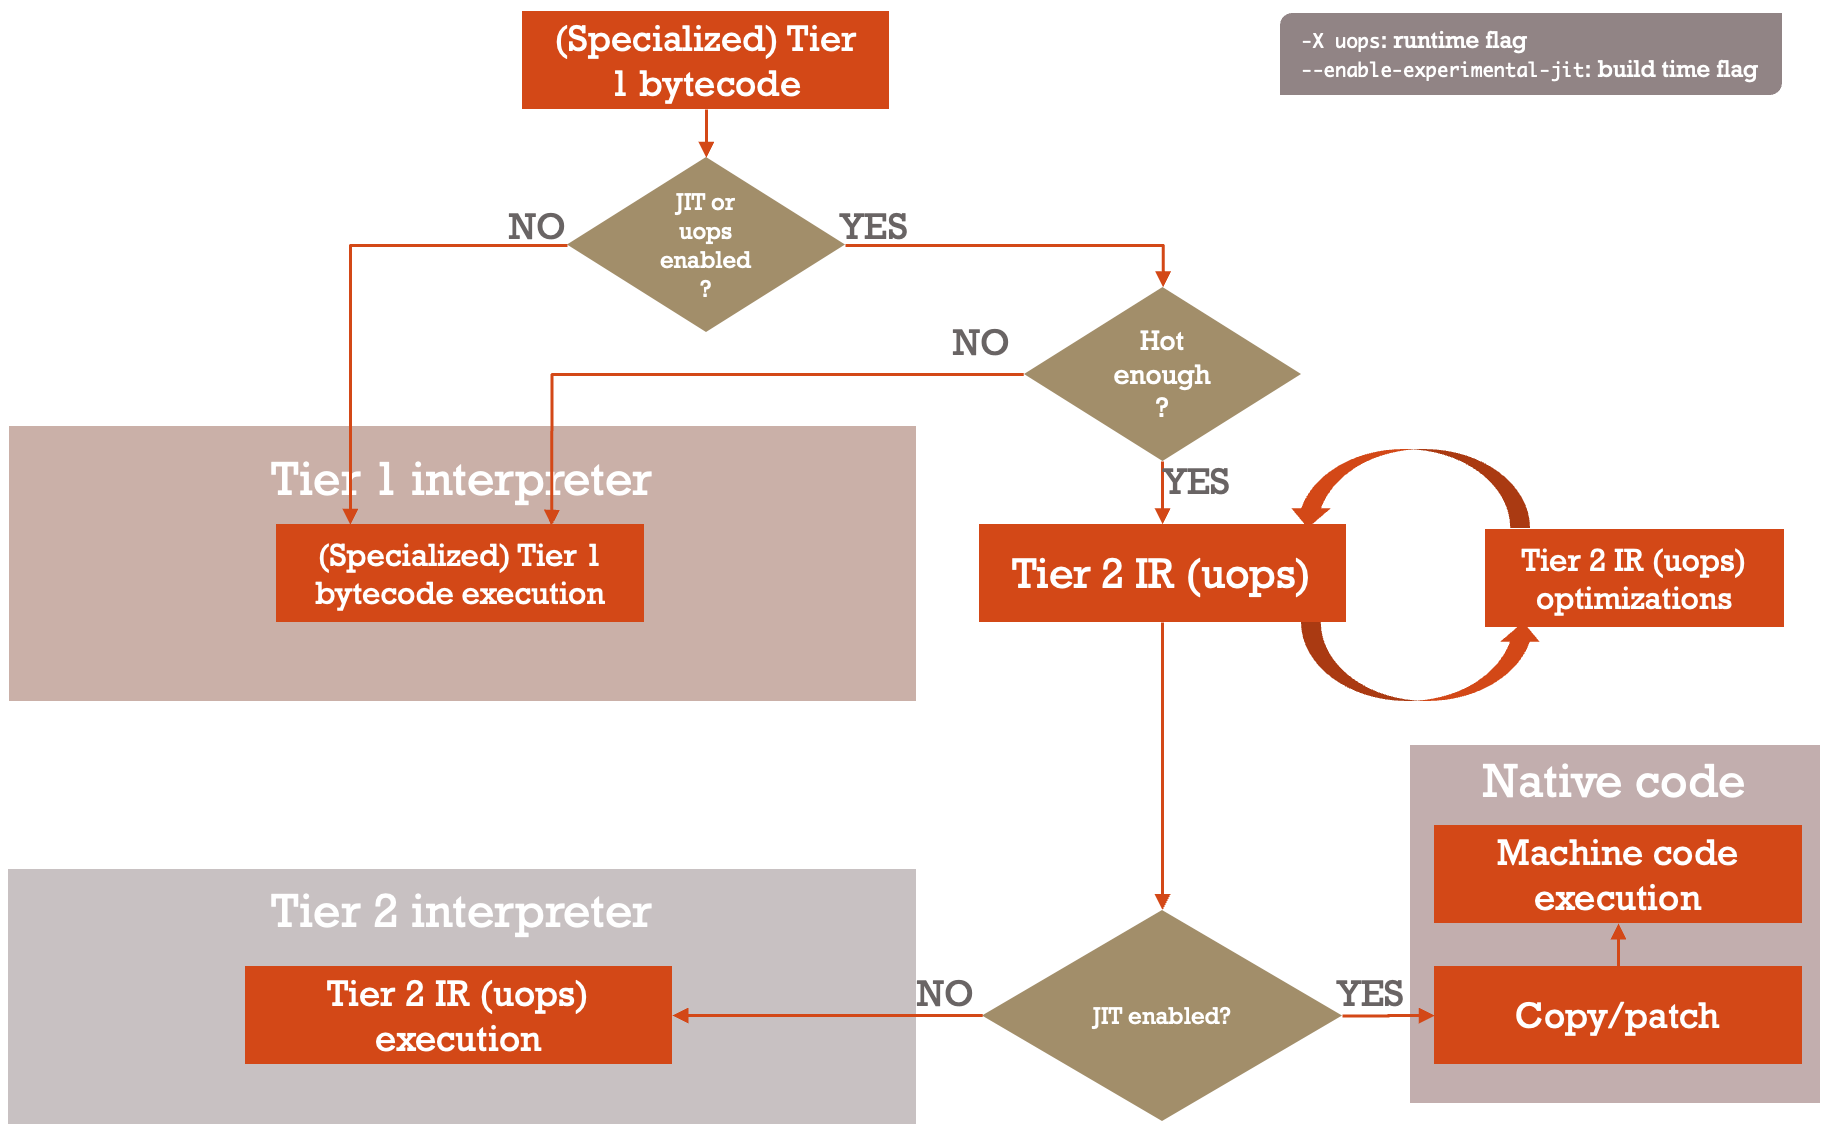
</div></center>

In [ ]:
from numba import njit
import numpy as np
from time import perf_counter

@njit
def go_fast(a):
    trace = 0.0
    for i in range(a.shape[0]):
        trace += np.tanh(a[i, i])
    return a + trace

x = np.arange(100).reshape(10, 10)
start = perf_counter()
result = go_fast(x)  # первый вызов — компиляция
print("Время:", perf_counter() - start)

#### .pyc

* platform independent
* version sensitive
* structure
    * magic
    * mtime
    * code object

<center><div>
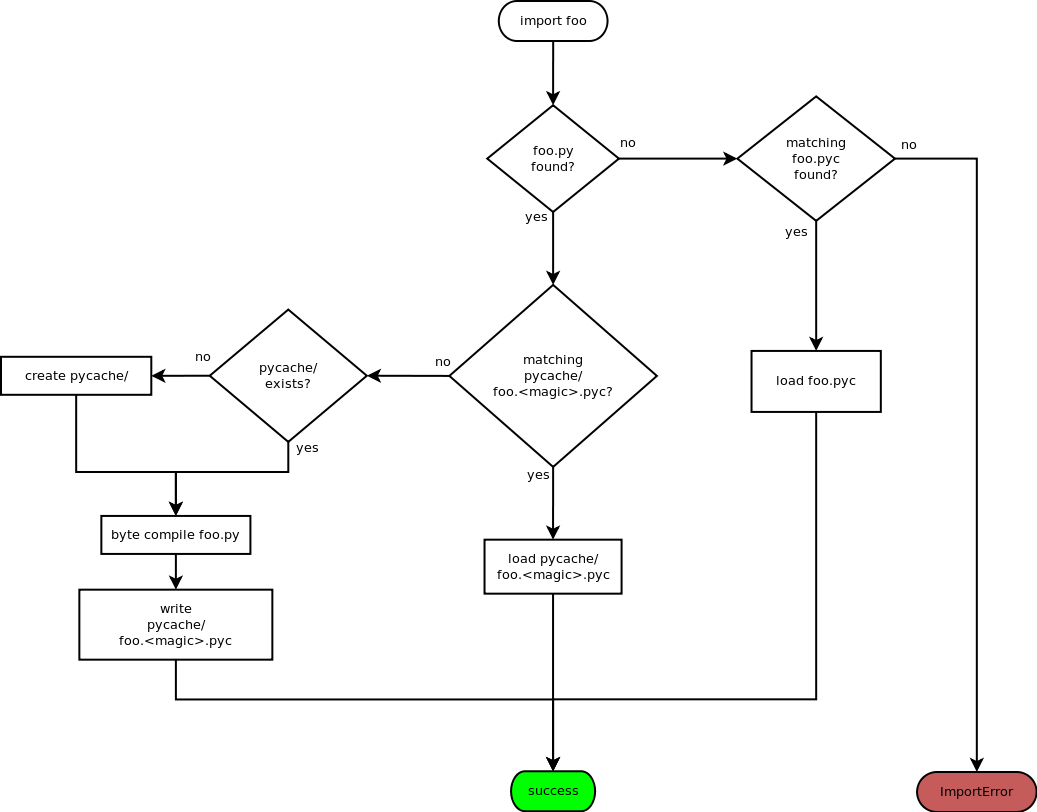
</div></center>

## CPython

#### Source structure

In [ ]:
%env SOURCE /src/cpython

In [ ]:
! cd $SOURCE && git rev-parse --abbrev-ref HEAD

In [ ]:
! ls -1 $SOURCE

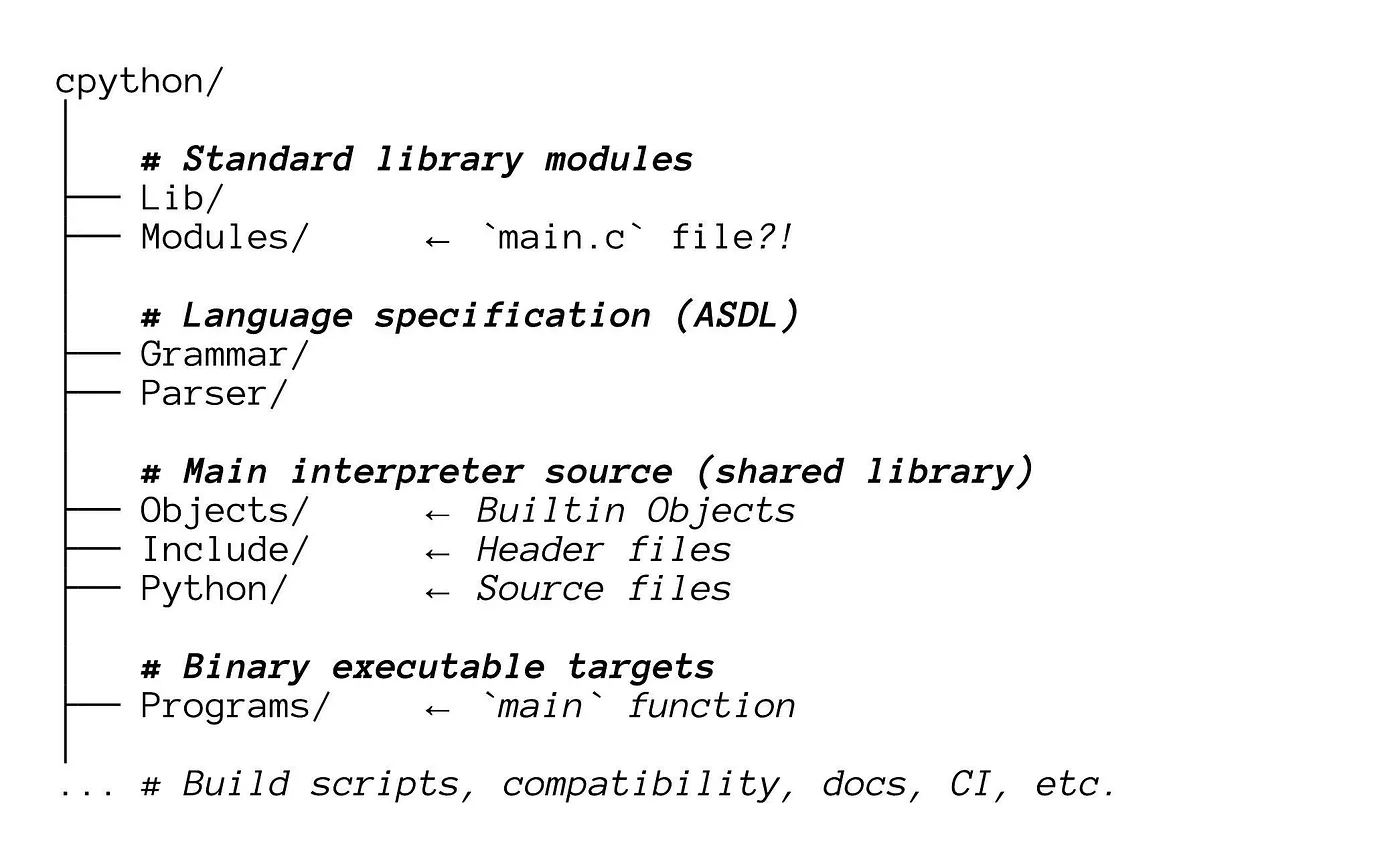

#### Simple program

In [1]:
! python -c 'sum([1, 2, 3]) + 42'

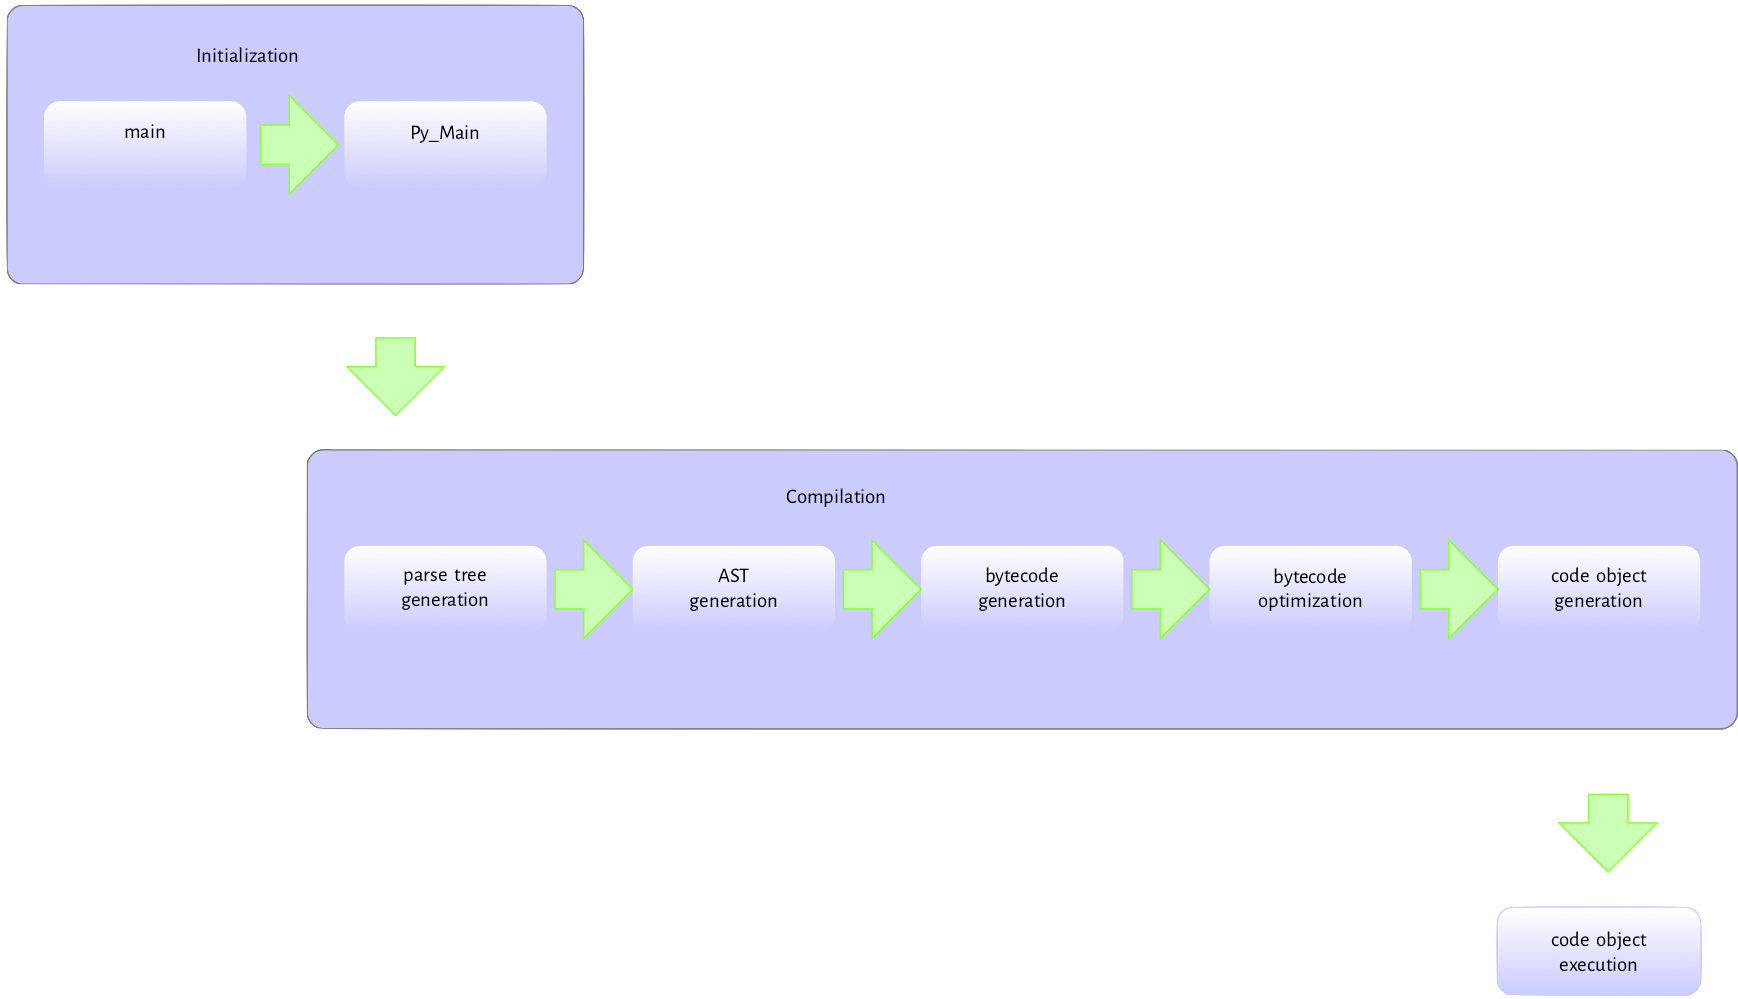

* ./Modules/python.c: main
* ./Modules/main.c: Py_Main
    * parse arguments
    * see if environment variables should affect behaviour
    * etc.
* ./Python/pythonrun.c: Py_Initialize - assembles interpreter
    * interpreter state
    * thread state
    * sys
    * builtins
* ./Python/pythonrun.c: PyRun_SimpleStringFlags - called with `-c`
    * \__main\__
* ./Parser/pgen.c
    * tokenize
    * Concrete Syntax Tree (CST) (parse tree)
* Python/ast.c
    * CST to Abstract Syntax Tree (AST)
* ./Python/compile.c 
    * AST to Control Flow Graph
    * CFG to code object 
* ./Python/pythonrun.c: run_mod, v = PyEval_EvalCode(co, globals, locals);
    * frame object (thread state point to stack of frames)
* ./Python/ceval.c: PyEval_EvalFrameEx.
    * execute opcode by opcode
* ./Python/pythonrun.c: Py_Finalize

#### Compilation

__Compiler architecture__

<center><div>
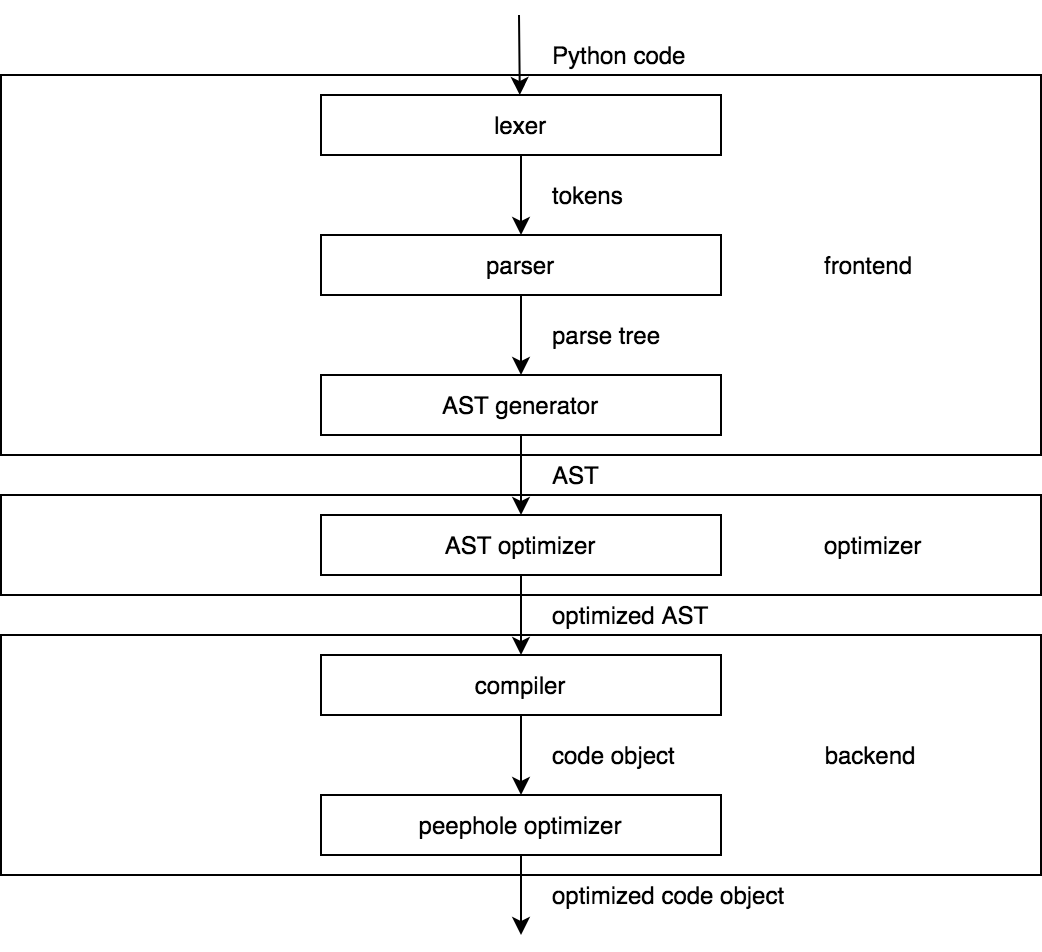
</div></center>

__a+1 CST__

<center><div>
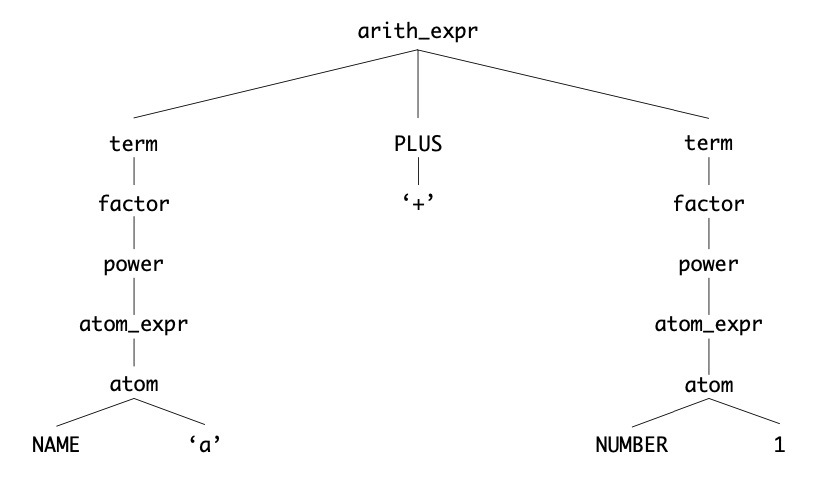
</div></center>

__a+1 AST__

<center><div>
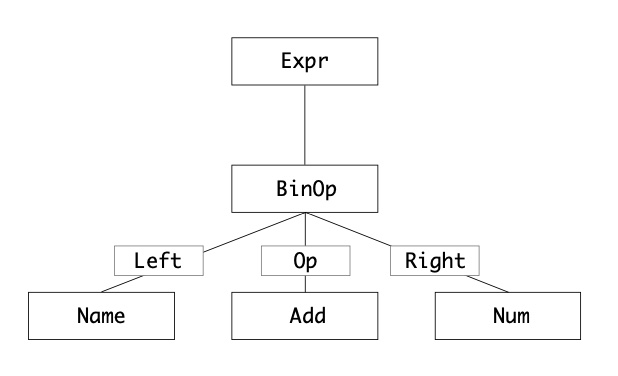
</div></center>

In [23]:
import ast
import dis
source = 'sum([1, 2, 3]) + 42' #kjhkjhkjjhkj

print(ast.dump(node), end="\n\n")
codeobj = compile(node, '<string>', mode='eval')
dis.disassemble(codeobj)
print(eval(codeobj))

Expression(body=BinOp(left=Call(func=Name(id='sum', ctx=Load()), args=[List(elts=[Constant(value=1), Constant(value=2), Constant(value=3)], ctx=Load())]), op=Add(), right=Constant(value=42)))

  0           RESUME                   0

  1           LOAD_NAME                0 (sum)
              PUSH_NULL
              BUILD_LIST               0
              LOAD_CONST               0 ((1, 2, 3))
              LIST_EXTEND              1
              CALL                     1
              LOAD_CONST               1 (42)
              BINARY_OP                0 (+)
              RETURN_VALUE
48


#### Code objects

In [24]:
# everything is code object!
print(compile('sum([1, 2, 3])', '', 'single'))
exec(compile('sum([1, 2, 3])', '', 'single'))

<code object <module> at 0x10eb7e100, file "", line 1>


6

Code execution in CPython is really the evaluation (interpretation) of a code object

In [ ]:
! grep -A46 "struct PyCodeObject {" $SOURCE/Include/cpython/code.h

In [25]:
def return42(): 
    return 42
print(dir(return42.__code__))

['__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__replace__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '_co_code_adaptive', '_varname_from_oparg', 'co_argcount', 'co_cellvars', 'co_code', 'co_consts', 'co_exceptiontable', 'co_filename', 'co_firstlineno', 'co_flags', 'co_freevars', 'co_kwonlyargcount', 'co_lines', 'co_linetable', 'co_lnotab', 'co_name', 'co_names', 'co_nlocals', 'co_positions', 'co_posonlyargcount', 'co_qualname', 'co_stacksize', 'co_varnames', 'replace']


co_code, co_consts, co_names, co_varnames, co_freevars,
co_cellvars, co_filename, co_firstlineno, co_flags, co_stacksize

* co_name
    * A name (a string) for this code object; for a function this would be the function’s name, for a class this would be the class’ name, etc. The compile builtin doesn’t let you specify this, so all code objects generated with it carry the name <module>.
* co_filename
    * The filename from which the code was compiled. Will be <stdin> for code entered in the interactive interpreter or whatever name is given as the second argument to compile for code objects created with compile.
Different types of names (string tuples)
* co_varnames
    * A tuple containing the names of the local variables (including arguments). To parse this tuple properly you need to look at co_flags and the counter fields listed below, so you’ll know which item in the tuple is what kind of variable. In the ‘richest’ case, co_varnames contains (in order): positional argument names (including optional ones), keyword only argument names (again, both required and optional), varargs argument name (i.e., *args), kwds argument name (i.e., **kwargs), and then any other local variable names.
* co_cellvars
    * A tuple containing the names of local variables that are stored in cells because they are referenced by lexically nested functions.
* co_freevars
    * A tuple containing the names of free variables. Generally, a free variable means a variable which is referenced by an expression but isn’t defined in it. It means a variable that is referenced in this code object but was defined and will be dereferenced to a cell in another code object.
* co_names
	* A tuple containing the names which aren’t covered by any of the other fields (they are not local variables, they are not free variables, etc) used by the bytecode. This includes names deemed to be in the global or builtin namespace as well as attributes (i.e., if you do foo.bar in a function, bar will be listed in its code object’s names).
* co_firstlineno
	* The line offset where the code object’s source code began, relative to the module it was defined in, starting from one. In this, each input line typed in the interactive interpreter is a module of its own.
* co_code
	* A string representing the sequence of bytecode instructions, contains a stream of opcodes and their operands (or rather, indexes which are used with other code object fields to represent their operands, as we saw above).
* co_consts
	* A tuple containing the literals used by the bytecode.
* co_lnotab
	* A string encoding the mapping from bytecode offsets to line numbers. ./Python/compile.c or ./Lib/dis.py: findlinestarts.
* co_flags
	* An integer encoding a number of flags regarding the way this code object was created. The list of possible flags is listed in ./Include/code.h, as a small example: CO_NESTED, which marks a code object which was compiled from a lexically nested function. Flags also have an important role in the implementation of the \__future\__ mechanism.
* co_exceptiontable
	* https://devguide.python.org/internals/interpreter/#error-handling

#### Frames

def c():
    return 42

def b():
    return c()

def a():
    return b()

a()



a

* Call stack is a stack data structure that stores information about the active subroutines of a computer program 
    * composed of stack frames
* Stack frame corresponds to a call to a subroutine which has not yet terminated with a return

In [ ]:
! grep -A23 "struct _frame {" $SOURCE/Include/cpython/frameobject.h

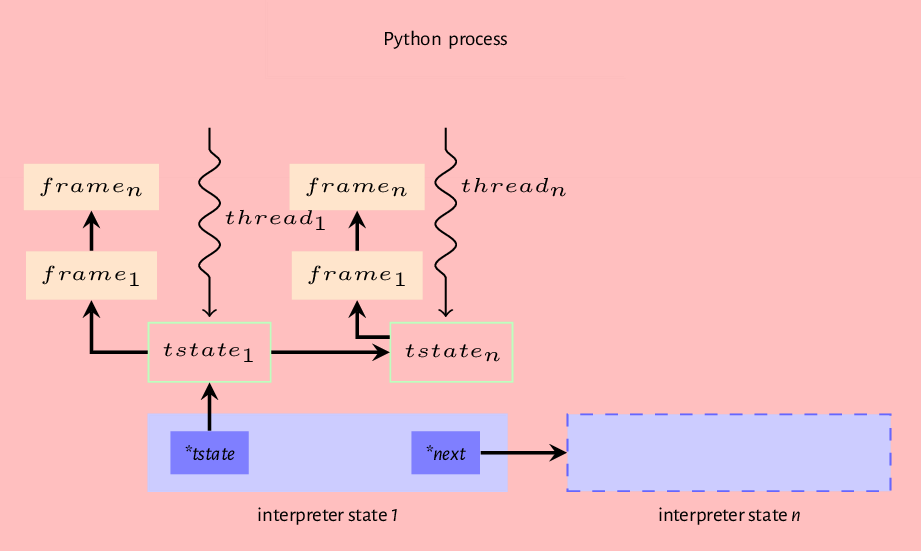

* every frame represents a currently-being-evaluated code object (f_code)
* frame objects are linked to one another, thus forming a call stack of frames
* inside each frame object in the call stack there’s a reference to value stack 

* Frame creation occurs whenever a code object should be evaluated
    * a function is called
    * a module is imported (the module’s top-level code is executed)
    * a class is defined
    * for every discrete command entered in the interactive interpreter
    * when the builtins eval or exec are used
    * when the -c switch is used 

* Optimizations (comments at Objects/frameobject.c)
    * co_zombieframe
    * free_list

__value stack - LOAD, STORE__
* LOAD_NAME and STORE_NAME
    * dictionary lookup
* LOAD_FAST and STORE_FAST
    * local namespace implemented with a statically sized array
* LOAD_GLOBAL and STORE_GLOBAL
* LOAD_DEREF and STORE_DEREF
    * if a variable is seen to be resolved from a lexically nested function, it will not be stored and will not be accessed using the regular naming opcodes. Instead, a special object called a cell is created to store the value of the object. When various code objects (the outer function, the inner function, etc) will access this variable, the use of the *\_DEREF opcodes will cause the cell to be accessed rather than the namespace of the accessing code object

#### Eval loop

* VM part of interptreter executes bytecode
    * simple stack machine
    * PyObject* stack - bytecode operates on objects
        * stack frames allocated on the heap
    * VM knows nothing about concrete types
    * Object know nothing about VM

In [ ]:
_PyEval_EvalFrameDefault(PyThreadState *tstate, PyFrameObject *f, int throwflag)
{
    /* variable declaration and initialization stuff */
    for (;;) {
        /* do periodic housekeeping once in a few opcodes */
        opcode = NEXTOP();
        if (HAS_ARG(opcode)) oparg = NEXTARG();
        switch (opcode) {
            case NOP:
                goto fast_next_opcode;
            /* lots of more complex opcode implementations */
            default:
                /* become rather unhappy */
        }
        /* handle exceptions or runtime errors, if any */
    }
    /* we are finished, pop the frame stack */
    tstate->frame = f->f_back;
    return retval;
}

In [ ]:
! grep -A25 BINARY_ADD $SOURCE/Python/ceval.c

In [ ]:
! grep -A13 PyNumber_Add  $SOURCE/Objects/abstract.c

* Computed-GOTOs
    * https://eli.thegreenplace.net/2012/07/12/computed-goto-for-efficient-dispatch-tables
    * compilers optimize “switch” statement as a single indirect branch instruction with a lookup table of addresses
    * create an explicit jump table and place an explicit indirect jump instruction at the end of each opcode

In [ ]:
! head $SOURCE/Python/opcode_targets.h

In [ ]:
TARGET(NOP)
    FAST_DISPATCH();

In [ ]:
TARGET_NOP:
    opcode = NOP;
    if (HAS_ARG(NOP))
        oparg = NEXTARG();
case NOP:
    {
        if (!_Py_TracingPossible) {
            f->f_lasti = INSTR_OFFSET();
            goto *opcode_targets[*next_instr++];
        }
        goto fast_next_opcode;
    }


#### Object

In [ ]:
! grep -B4 "} PyObject;" $SOURCE/Include/object.h

In [ ]:
! grep -A3 "define _PyObject_HEAD_EXTRA " $SOURCE/Include/object.h

* ob_refcnt
    * reference counting, garbage collection
    * Py_DECREF, Py_INCREF
* ob_type
    * PyNumber_Add handles int, floats, etc

In [ ]:
! grep -A82 "struct _typeobject {" $SOURCE/Include/cpython/object.h

* new type (class) inherits slots from parent
* type_new
    * fixup_slot_dispatchers

Protocols
* Object
* Buffer
* Number
* Mapping
* Sequence

### References

* https://devguide.python.org/internals/
* https://leanpub.com/insidethepythonvirtualmachine/
* https://tenthousandmeters.com/tag/python-behind-the-scenes/
* https://blog.sourcerer.io/python-internals-an-introduction-d14f9f70e583
* https://blog.codingconfessions.com/p/cpython-reference-counting-internals
* https://www.python.org/dev/peps/pep-0339/
* https://lwn.net/Articles/939981/
* https://www.fluentpython.com/extra/internals-of-sets-and-dicts/
* https://tonybaloney.github.io/posts/python-gets-a-jit.html
* https://realpython.com/products/cpython-internals-book/
* https://habr.com/post/314062/
* https://www.youtube.com/watch?v=HVUTjQzESeo
* http://eli.thegreenplace.net/tag/python-internals
* https://www.youtube.com/watch?v=mxjv9KqzwjI
* https://indianpythonista.wordpress.com/2018/01/05/demystifying-pyc-files/
* https://www3.hhu.de/stups/downloads/pdf/BoCuFiRi09_246.pdf
* https://hacks.mozilla.org/2017/02/a-crash-course-in-just-in-time-jit-compilers/
* https://docs.python.org/3.12/reference/executionmodel.html
* https://nedbatchelder.com/blog/200804/the_structure_of_pyc_files.html